**MSB1015 - Maastricht University**

Now that we have collected our data, we can move on to some data visualization to understand our data at a better level.

I want to show the following things:
* Class balance
* Distributions
* Correlation heatmap
* PCA


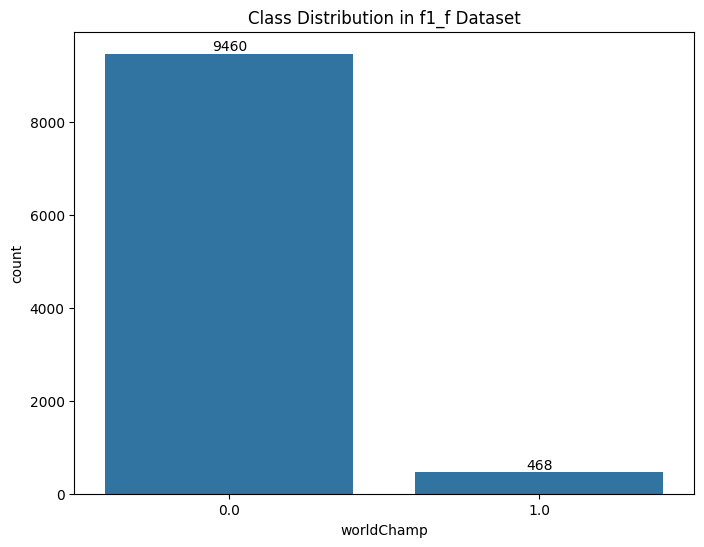

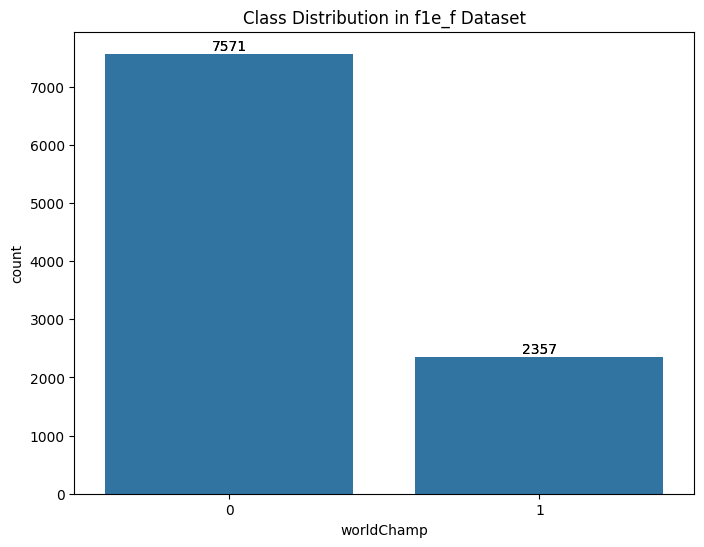

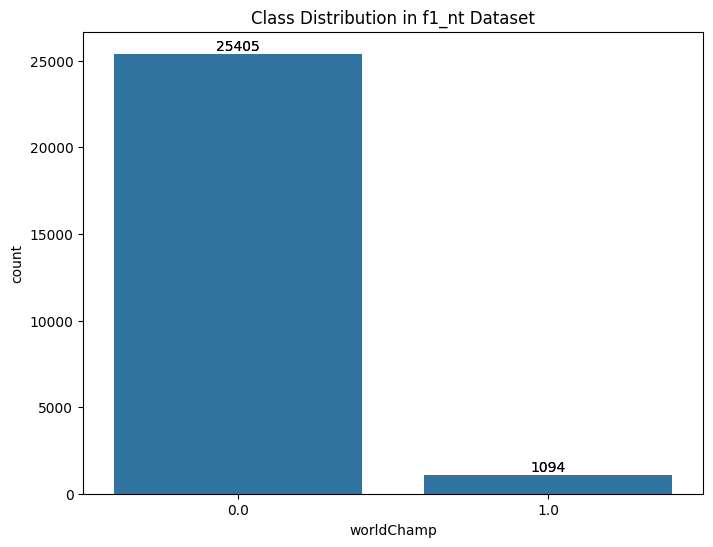

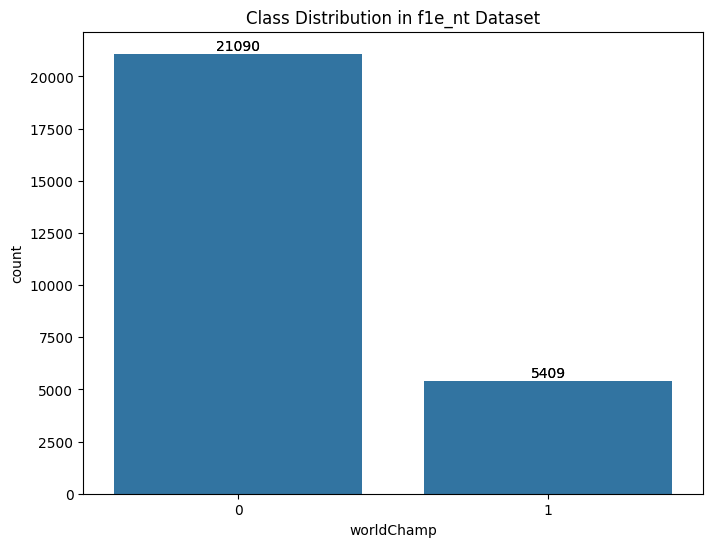

In [ ]:
# class balance plot and class balancing

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA
import numpy as np
from sklearn.preprocessing import StandardScaler

# create PCA plot on the once per season champion dataset (f1_f.csv)
# load the dataset
df_f = pd.read_csv("d:\\Maastricht University\\MSB1015\\ML\\Data\\f1_f.csv")

# class imbalance bar plot, show number of worldChamp and non-worldChamp in the dataset on the same plot
plt.figure(figsize=(8,6))
ax = sns.countplot(x='worldChamp', data=df_f)
plt.title('Class Distribution in f1_f Dataset')

# add count labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width()/2., p.get_height()), 
                ha='center', va='bottom')

plt.show()

df_fe = pd.read_csv("d:\\Maastricht University\\MSB1015\\ML\\Data\\f1e_f.csv")

# class imbalance bar plot for f1e_f 
plt.figure(figsize=(8,6))
ax = sns.countplot(x='worldChamp', data=df_fe)
plt.title('Class Distribution in f1e_f Dataset')

# add count labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width()/2., p.get_height()), 
                ha='center', va='bottom')

# add count labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width()/2., p.get_height()), 
                ha='center', va='bottom')

plt.show()

df_nt = pd.read_csv("d:\\Maastricht University\\MSB1015\\ML\\Data\\f1_nt.csv")

# class imbalance bar plot for f1_nt
plt.figure(figsize=(8,6))
ax = sns.countplot(x='worldChamp', data=df_nt)
plt.title('Class Distribution in f1_nt Dataset')

# add count labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width()/2., p.get_height()), 
                ha='center', va='bottom')

# add count labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width()/2., p.get_height()), 
                ha='center', va='bottom')

plt.show()

dfe_nt = pd.read_csv("d:\\Maastricht University\\MSB1015\\ML\\Data\\f1e_nt.csv")

# class imbalance bar plot for f1_nt
plt.figure(figsize=(8,6))
ax = sns.countplot(x='worldChamp', data=dfe_nt)
plt.title('Class Distribution in f1e_nt Dataset')

# add count labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width()/2., p.get_height()), 
                ha='center', va='bottom')

# add count labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width()/2., p.get_height()), 
                ha='center', va='bottom')

plt.show()


As can be seen, in the f1 normal dataset we do have heavy class imbalancing. This will be dealt with in the 3rd script, Data_ML. For now, lets move on to correlation heatmaps. 

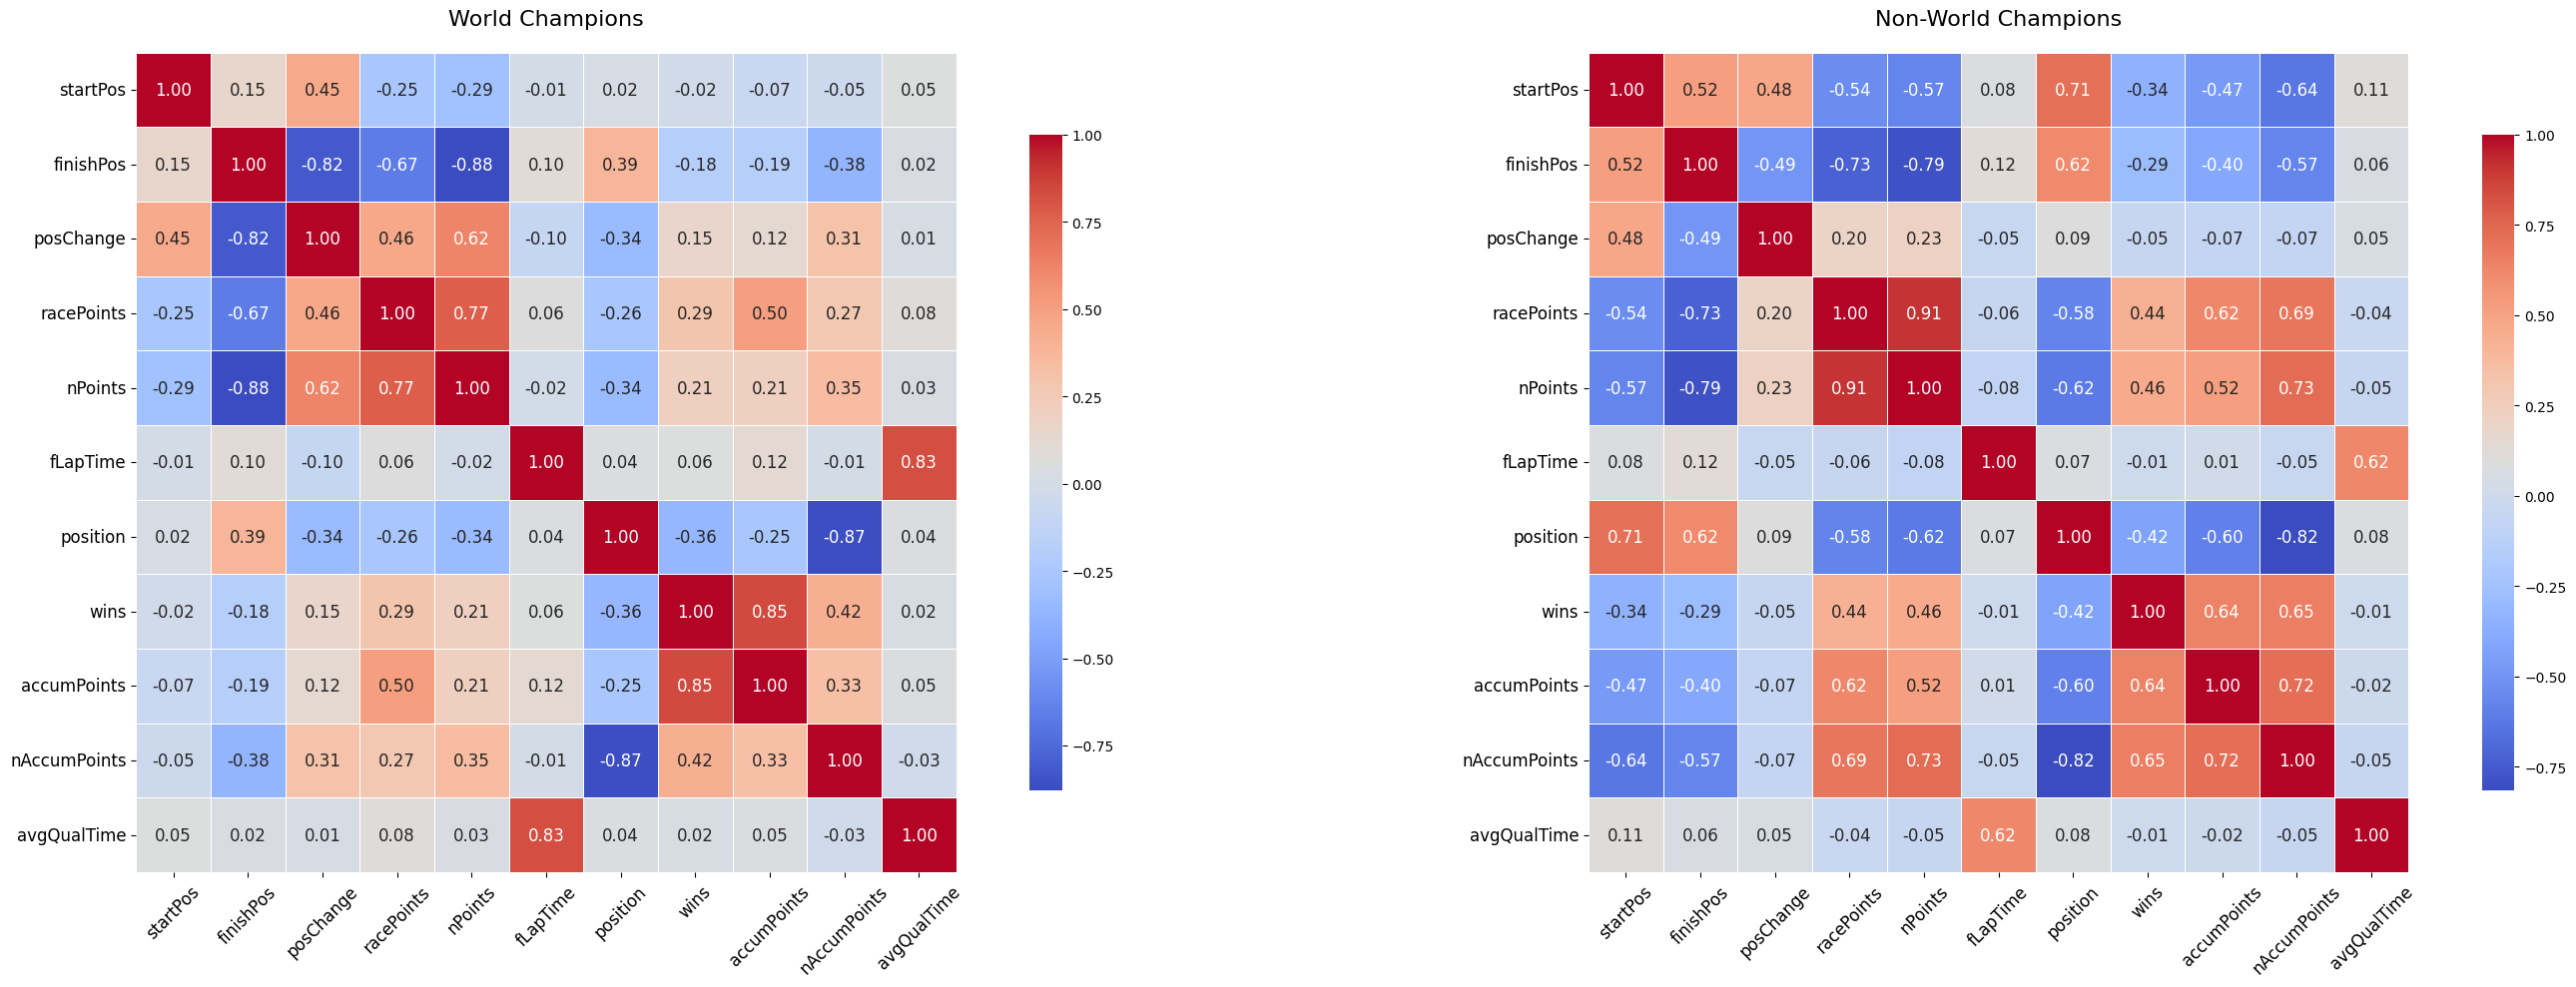

In [ ]:
# fixed correlation heatmaps
world_champs_f = df_f[df_f['worldChamp'] == 1]
non_world_champs_f = df_f[df_f['worldChamp'] == 0]

# define columns to exclude, mostly ids and stuff like that that isnt important
exclude_cols = ['worldChamp', 'driverId', 'raceId', 'constructorId', 'year', 'round', 'circuitId']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(30, 10))

# world Champions correlation heatmap
numeric_df_f = world_champs_f.select_dtypes(include=[np.number]).drop(columns=[col for col in exclude_cols if col in world_champs_f.columns])
correlation_matrix_f = numeric_df_f.corr()
sns.heatmap(correlation_matrix_f, 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            square=True, 
            linewidths=0.5, 
            cbar_kws={"shrink": .8},
            annot_kws={"size": 12},
            ax=ax1)
ax1.set_title('World Champions', fontsize=16, pad=20)
ax1.tick_params(axis='x', rotation=45, labelsize=12)
ax1.tick_params(axis='y', rotation=0, labelsize=12)

# non-World Champions correlation heatmap
numeric_df_f_non = non_world_champs_f.select_dtypes(include=[np.number]).drop(columns=[col for col in exclude_cols if col in non_world_champs_f.columns])
correlation_matrix_f_non = numeric_df_f_non.corr()
sns.heatmap(correlation_matrix_f_non, 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm',
            square=True, 
            linewidths=0.5, 
            cbar_kws={"shrink": .8},
            annot_kws={"size": 12},
            ax=ax2)
ax2.set_title('Non-World Champions', fontsize=16, pad=20)
ax2.tick_params(axis='x', rotation=45, labelsize=12)
ax2.tick_params(axis='y', rotation=0, labelsize=12)

plt.tight_layout()
plt.show()

C:\Users\Gebruiker\AppData\Local\Temp\ipykernel_23972\1824814036.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=target_corr_df.reset_index(), y='index', x='correlation',


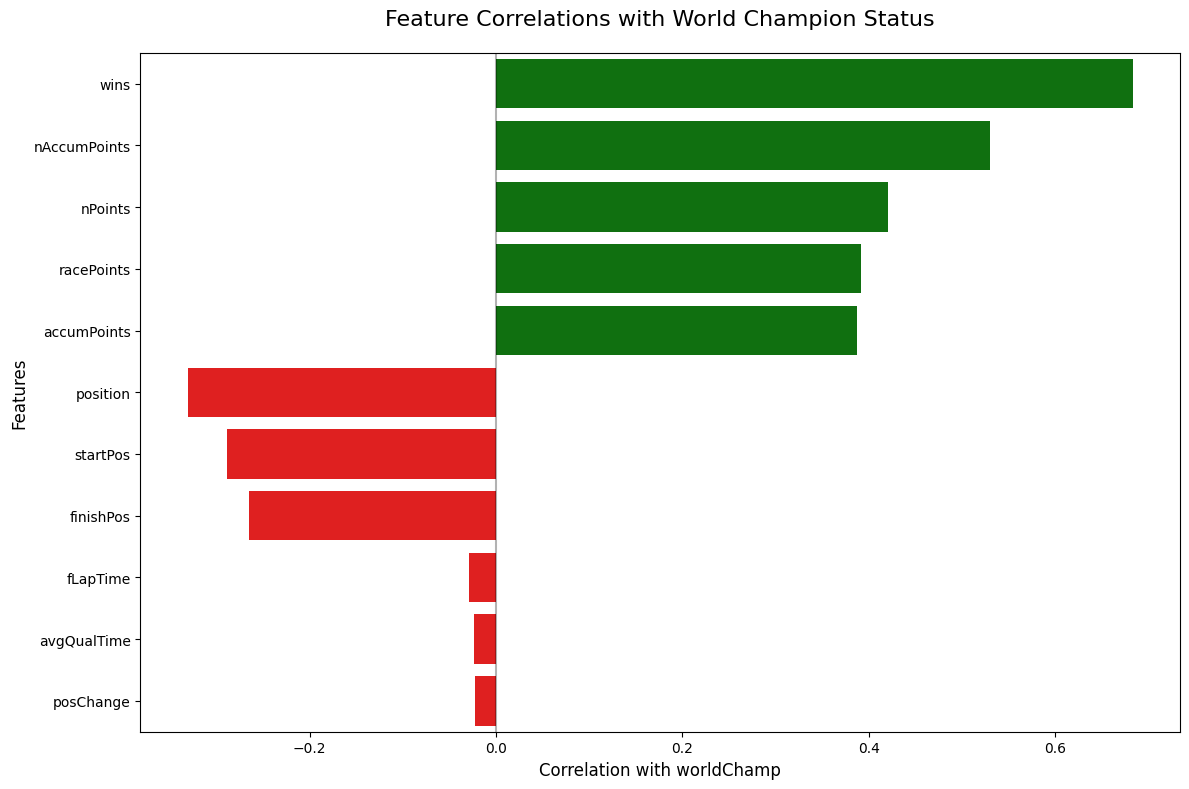

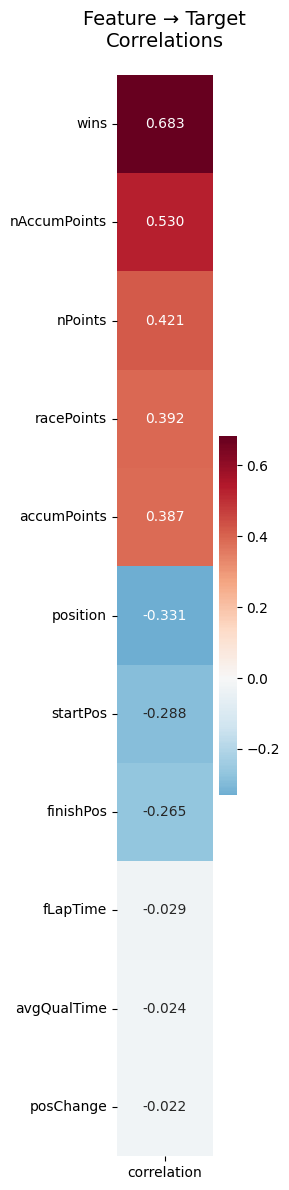

In [ ]:
# feature-target heatmap
all_numeric_features = df_f.select_dtypes(include=[np.number])

# exclude only the ID columns, but keep worldChamp for correlation calculation
exclude_cols_for_target = ['driverId', 'raceId', 'constructorId', 'year', 'round', 'circuitId']
features_for_target = all_numeric_features.drop(columns=[col for col in exclude_cols_for_target if col in all_numeric_features.columns])

target_correlations = features_for_target.corr()['worldChamp'].drop('worldChamp').sort_values(key=abs, ascending=False)

# visualize feature-to-target correlations
plt.figure(figsize=(12, 8))
target_corr_df = target_correlations.to_frame('correlation')
sns.barplot(data=target_corr_df.reset_index(), y='index', x='correlation', 
            palette=['red' if x < 0 else 'green' for x in target_corr_df['correlation']])
plt.title('Feature Correlations with World Champion Status', fontsize=16, pad=20)
plt.xlabel('Correlation with worldChamp', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.tight_layout()
plt.show()

# heatmap of just the target correlations
plt.figure(figsize=(3, 12))
sns.heatmap(target_corr_df, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            cbar_kws={'shrink': 0.8})
plt.title('Feature → Target\nCorrelations', fontsize=14, pad=20)
plt.tight_layout()
plt.show()